## Bengaluru Traffic & Road Safety Analysis

## 🏙️ Project Introduction

Bengaluru is one of India's major metropolitan cities, with a large and complex road-traffic environment. This project analyzes road crashes, fatalities, injuries, traffic violations, enforcement activity, fine collection, automation, and drink-driving cases to understand major road-safety patterns and enforcement challenges.

The analysis uses multiple datasets covering city-level crash trends, police-station-level crashes, traffic violations, enforcement and fines, and monthly drink-driving cases. Using Python, Pandas, Matplotlib, and Seaborn, the project performs data cleaning, exploratory data analysis, trend analysis, geographic analysis, violation analysis, KPI analysis, and correlation analysis.

The main objective is to identify high-risk areas, major traffic violations, changes in crash patterns, enforcement trends, and important relationships between road-safety and enforcement indicators. These findings can help support data-driven road-safety planning and targeted enforcement strategies.

## Importing All Required Libraries

In [1]:
import numpy as np

import pandas as pd 

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [2]:
file_path = "Bengaluru road crashes & enforcement.xlsx"

city = pd.read_excel(file_path, sheet_name="City_Crashes")
station = pd.read_excel(file_path, sheet_name="Station_Crashes")
violations = pd.read_excel(file_path, sheet_name="Violations")
fines = pd.read_excel(file_path, sheet_name="Cases_Fines")
drink_drive = pd.read_excel(file_path, sheet_name="Drink_Drive_Monthly")

## Data Understanding

In [3]:
print("Station_Crashes:", station.shape)
print("City_Crashes:", city.shape)
print("Violations:", violations.shape)
print("Cases_Fines:", fines.shape)
print("Drink_Drive_Monthly:", drink_drive.shape)

Station_Crashes: (372, 12)
City_Crashes: (20, 9)
Violations: (321, 6)
Cases_Fines: (16, 17)
Drink_Drive_Monthly: (28, 5)


In [4]:
city.head()
station.head()
violations.head()
fines.head()
drink_drive.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1.0,year,month_num,month,drink_drive_cases
1,NaN,NaN,NaN,NaN,NaN
2,2.0,2016,1,January,4990
3,3.0,2016,2,February,5158
4,4.0,2016,3,March,5641


In [5]:
city.shape
city.info()
city.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     19 non-null     float64
 1   fatal_crashes            19 non-null     float64
 2   killed                   19 non-null     float64
 3   non_fatal_crashes        19 non-null     float64
 4   total_crashes            19 non-null     float64
 5   fatality_rate_pct        19 non-null     float64
 6   yoy_change_total_pct     19 non-null     float64
 7   yoy_change_killed_pct    17 non-null     float64
 8   yoy_change_killed_pct.1  17 non-null     float64
dtypes: float64(9)
memory usage: 1.5 KB


,year,fatal_crashes,killed,non_fatal_crashes,total_crashes,fatality_rate_pct,yoy_change_total_pct,yoy_change_killed_pct,yoy_change_killed_pct.1
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,17.000000,17.000000
mean,11.000000,2016.000000,755.789474,784.421053,4661.315789,5417.105263,14.626316,-1.435294,0.076471
std,5.627314,5.627314,95.587411,95.640133,1388.820565,1443.567567,3.145692,20.667878,11.438833
min,2.000000,2007.000000,609.000000,642.000000,2592.000000,3213.000000,10.000000,-32.500000,-19.000000
25%,6.500000,2011.500000,712.500000,738.500000,3947.000000,4728.500000,12.050000,-8.600000,-9.100000
50%,11.000000,2016.000000,740.000000,766.000000,4293.000000,5004.000000,14.200000,-5.000000,0.400000
75%,15.500000,2020.500000,829.500000,868.000000,5482.000000,6253.500000,17.450000,-0.700000,7.200000
max,20.000000,2025.000000,957.000000,981.000000,7469.000000,8426.000000,19.700000,55.500000,18.000000


In [6]:
station.info()
violations.info()
fines.info()
drink_drive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               371 non-null    float64
 1   zone               371 non-null    float64
 2   sub_division       371 non-null    object 
 3   station            151 non-null    object 
 4   station_raw        371 non-null    object 
 5   fatal_crashes      371 non-null    object 
 6   killed             371 non-null    float64
 7   non_fatal_crashes  268 non-null    float64
 8   injured            371 non-null    float64
 9   total_crashes      268 non-null    float64
 10  fatality_rate_pct  371 non-null    float64
 11  Unnamed: 11        371 non-null    float64
dtypes: float64(8), object(4)
memory usage: 35.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------

## Data Cleaning

In [7]:
city.isnull().sum()
station.isnull().sum()
violations.isnull().sum()
fines.isnull().sum()
drink_drive.isnull().sum()

Unnamed: 0    1
Unnamed: 1    1
Unnamed: 2    1
Unnamed: 3    1
Unnamed: 4    1
dtype: int64

In [8]:
# Remove all unwanted Unnamed colunm
city = city.loc[:, ~city.columns.astype(str).str.contains("Unnamed", case=False)]
station = station.loc[:, ~station.columns.astype(str).str.contains("Unnamed", case=False)]
violations = violations.loc[:, ~violations.columns.astype(str).str.contains("Unnamed", case=False)]
fines = fines.loc[:, ~fines.columns.astype(str).str.contains("Unnamed", case=False)]
drink_drive = drink_drive.loc[:, ~drink_drive.columns.astype(str).str.contains("Unnamed", case=False)]

In [9]:
city.duplicated().sum()
station.duplicated().sum()
violations.duplicated().sum()
fines.duplicated().sum()
drink_drive.duplicated().sum()

np.int64(0)

In [10]:
station.isnull().sum()

year                   1
zone                   1
sub_division           1
station              221
station_raw            1
fatal_crashes          1
killed                 1
non_fatal_crashes    104
injured                1
total_crashes        104
fatality_rate_pct      1
dtype: int64

In [11]:
station = station.dropna(how="all").reset_index(drop=True)

In [12]:
# Remove the unnecessary columns
station = station.drop(columns=["sub_division", "fatal_crashes"])

# Rename the remaining columns correctly
station.columns = [
    "year",
    "zone",
    "station",
    "fatal_crashes",
    "killed",
    "non_fatal_crashes",
    "injured",
    "total_crashes",
    "fatality_rate_pct"
]

# Check the result
station.head()

,year,zone,station,fatal_crashes,killed,non_fatal_crashes,injured,total_crashes,fatality_rate_pct
0,2.0,2018.0,NaN,Adugodi,3.0,3.0,47.0,53.0,50.0
1,3.0,2018.0,NaN,Airport (HAL),24.0,26.0,85.0,77.0,109.0
2,4.0,2018.0,NaN,Ashok Nagar,4.0,4.0,51.0,55.0,55.0
3,5.0,2018.0,NaN,Banaswadi,21.0,21.0,108.0,133.0,129.0
4,6.0,2018.0,NaN,Cubbon Park,2.0,2.0,52.0,53.0,54.0


In [13]:
station.isnull().sum()

year                   0
zone                   0
station              220
fatal_crashes          0
killed                 0
non_fatal_crashes    103
injured                0
total_crashes        103
fatality_rate_pct      0
dtype: int64

In [14]:
station["non_fatal_crashes"] = station["non_fatal_crashes"].fillna(0)
station["total_crashes"] = station["total_crashes"].fillna(0)

In [15]:
station.isnull().sum()

year                   0
zone                   0
station              220
fatal_crashes          0
killed                 0
non_fatal_crashes      0
injured                0
total_crashes          0
fatality_rate_pct      0
dtype: int64

##  Exploratory Data Analysis

## Crash trend analysis 

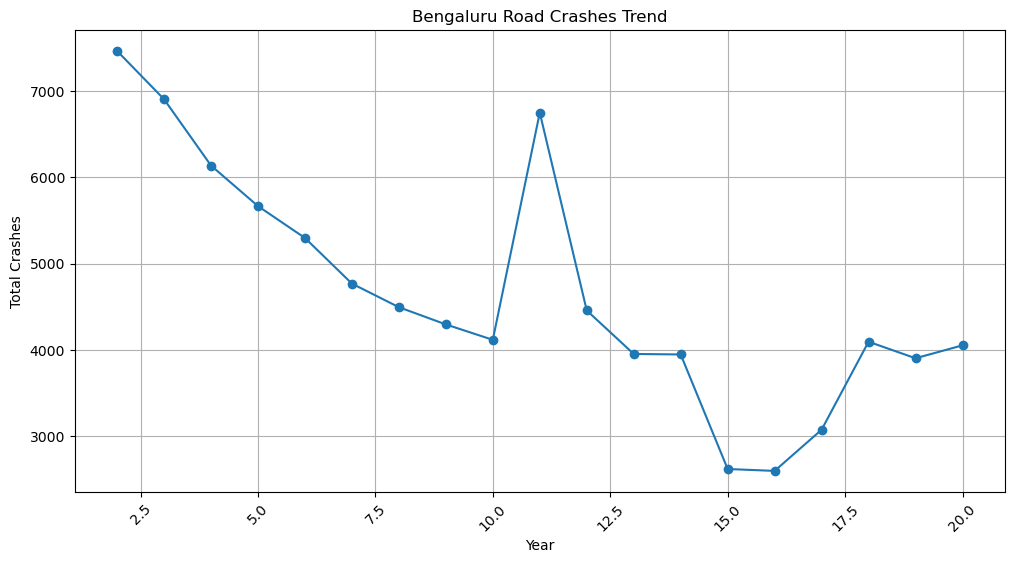

In [38]:
# Convert year to numeric
city["year"] = pd.to_numeric(city["year"], errors="coerce")

# Create graph
plt.figure(figsize=(12, 6))

plt.plot(
    city["year"],
    city["total_crashes"],
    marker="o"
)

plt.title("Bengaluru Road Crashes Trend")
plt.xlabel("Year")
plt.ylabel("Total Crashes")

plt.xticks(rotation=45)

plt.grid(True)
plt.show()

## Insight: 
The trend shows considerable variation in the number of road crashes across the years. Crash volume generally changes over time rather than following a constant pattern, with noticeable peaks and declines. 
This indicates that road-safety conditions and traffic-related factors have varied significantly across the study period

## Fatality rate analysis

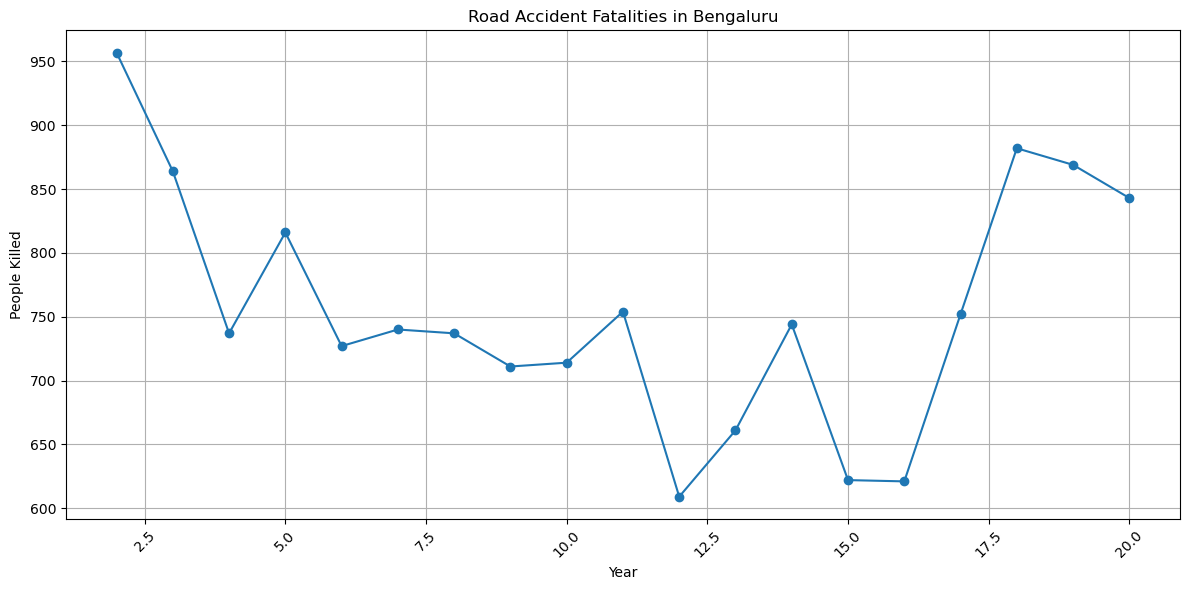

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    city["year"],
    city["killed"],
    marker="o"
)

plt.title("Road Accident Fatalities in Bengaluru")
plt.xlabel("Year")
plt.ylabel("People Killed")

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

## Insight:
The number of people killed in road accidents varies across the years. 
Periods with higher fatalities indicate years of greater road-safety severity and should be examined alongside total crash volume to determine whether more crashes also resulted in more deaths.

## Fatal vs Non-Fatal crashes

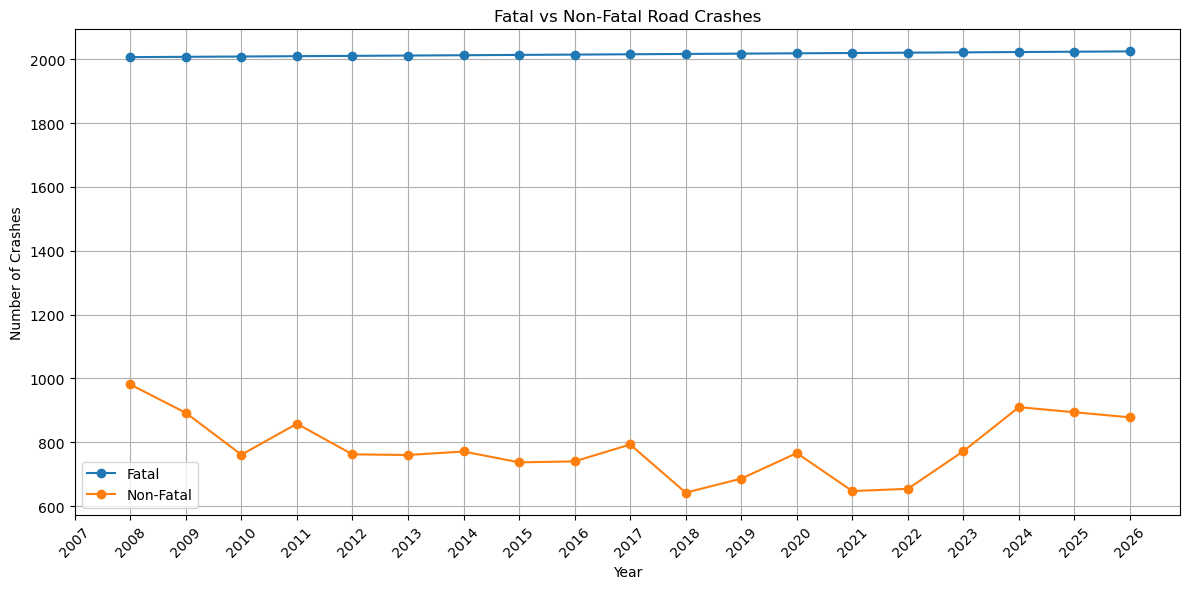

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    city["actual_year"],
    city["fatal_crashes"],
    marker="o",
    label="Fatal"
)

plt.plot(
    city["actual_year"],
    city["non_fatal_crashes"],
    marker="o",
    label="Non-Fatal"
)

plt.title("Fatal vs Non-Fatal Road Crashes")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")

plt.legend()
plt.xticks(city["actual_year"], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

## Insight: 
Non-fatal crashes account for a substantial share of reported crashes, while fatal crashes represent a smaller but significantly more severe portion. 
Comparing both trends helps identify whether changes in overall crash volume are accompanied by changes in crash severity.

## Year-over-Year analysis

In [57]:
city[[
    "year",
    "yoy_change_total_pct",
    "yoy_change_killed_pct"
]]

,year,yoy_change_total_pct,yoy_change_killed_pct
0,NaN,NaN,NaN
1,2.0,11.4,NaN
2,3.0,11.1,-7.8
3,4.0,10.7,-11.5
4,5.0,12.6,-5.7
5,6.0,12.1,-7.1
6,7.0,13.4,-8.6
7,8.0,14.1,-5.0
8,9.0,14.2,-4.3
9,10.0,14.8,-3.5


In [23]:
city.loc[
    city["yoy_change_total_pct"].idxmin()
]

year                         11.0
fatal_crashes              2016.0
killed                      754.0
non_fatal_crashes           793.0
total_crashes              6752.0
fatality_rate_pct          7506.0
yoy_change_total_pct         10.0
yoy_change_killed_pct        55.5
yoy_change_killed_pct.1       7.2
actual_year                2017.0
Name: 10, dtype: float64

## Insight:
Year-over-year analysis highlights the years in which crash numbers experienced the largest increases or decreases.
This provides a better understanding of short-term changes than a simple long-term trend.

## Station-level analysis

In [20]:
top_stations = (
    station.groupby("station")["total_crashes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_stations

station
North East     831.0
Whitefield     532.0
North          527.0
South          469.0
West           439.0
Vijayanagar    310.0
South East     308.0
East           274.0
HSR Layout     261.0
Central        240.0
Name: total_crashes, dtype: float64

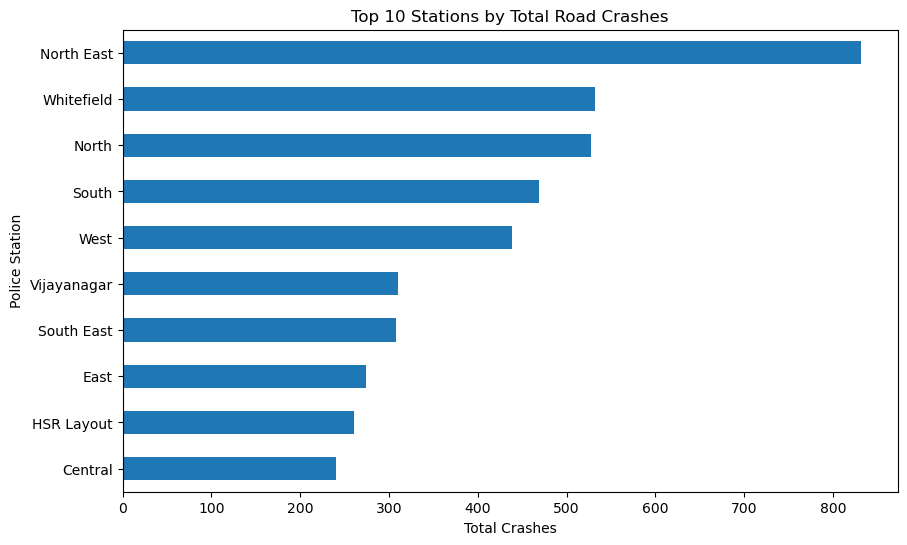

In [21]:
top_stations.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Stations by Total Road Crashes")
plt.xlabel("Total Crashes")
plt.ylabel("Police Station")

plt.show()

In [22]:
top_fatal = (
    station.groupby("station")["killed"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_fatal

station
North East     621.0
Whitefield     335.0
North          307.0
West           293.0
South          216.0
HSR Layout     194.0
South East     174.0
East           171.0
Vijayanagar    128.0
Central        102.0
Name: killed, dtype: float64

## Insight: 
North East records the highest number of crashes among the stations analyzed, followed by Whitefield and North. 
This indicates that crash risk is not evenly distributed across police-station areas and that specific locations may require targeted road-safety interventions

## Zone-level analysis

In [23]:
zone_analysis = (
    station.groupby("zone")
    .agg(
        total_crashes=("total_crashes", "sum"),
        fatal_crashes=("fatal_crashes", "sum"),
        killed=("killed", "sum"),
        injured=("injured", "sum")
    )
    .sort_values("total_crashes", ascending=False)
)

zone_analysis

,total_crashes,fatal_crashes,killed,injured
zone,,,,
2019.0,4250.0,AdugodiAirport (HAL)Ashok NagarBanaswadiCubbon...,746.0,3938.0
2023.0,4191.0,BanaswadiHalasooruIndiranagarK G HalliPulikesh...,882.0,4092.0
2018.0,4129.0,AdugodiAirport (HAL)Ashok NagarBanaswadiCubbon...,663.0,3948.0
2022.0,3218.0,AdugodiAirport (HAL)Ashok NagarBanaswadiCubbon...,751.0,3072.0
2021.0,2828.0,AdugodiAirport (HAL)Ashok NagarBanaswadiCubbon...,618.0,2593.0
2020.0,2760.0,AdugodiAirport (HAL)Ashok NagarBanaswadiCubbon...,622.0,2614.0
2024.0,0.0,BanaswadiHalasooruIndiranagarK G HalliPulikesh...,852.0,3948.0
2025.0,0.0,BanaswadiHalasooruIndiranagarK G HalliPulikesh...,807.0,4083.0


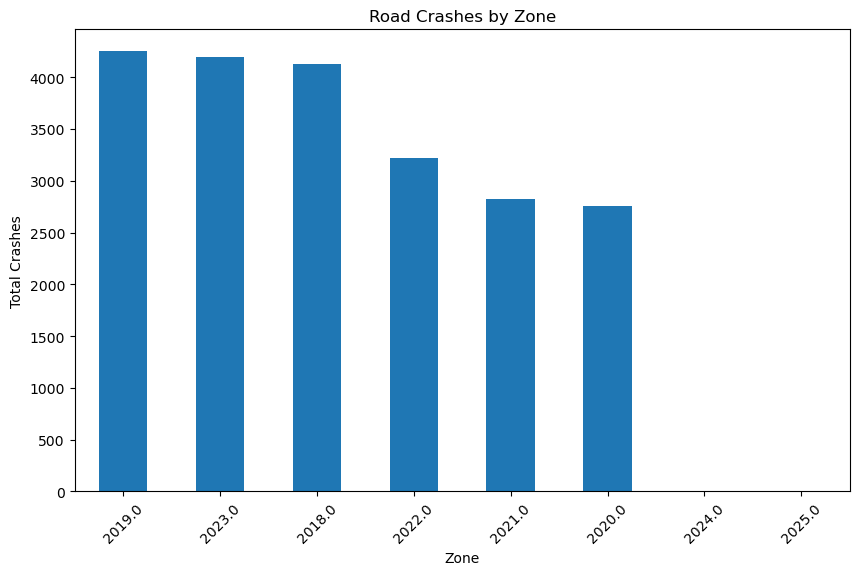

In [24]:
zone_analysis["total_crashes"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Road Crashes by Zone")
plt.xlabel("Zone")
plt.ylabel("Total Crashes")
plt.xticks(rotation=45)

plt.show()

## Insight: 
The zone-level analysis helps identify geographic differences in road-crash concentration.
Comparing zones can reveal where road-safety resources and enforcement efforts may need to be prioritized.

## Traffic violation analysis

In [25]:
top_offences = (
    violations.groupby("offence")["cases"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_offences

offence
Rider- without Helmet            24401960.0
Pillion Rider- without Helmet    14056994.0
Wrong parking                     8111182.0
Jumping traffic signal            6264062.0
Without Safety belt               2907951.0
No Entry                          2683232.0
Def. reg. no. plate               2324209.0
Using Mobile phone                1233354.0
Triple riding                      920827.0
Others                             767923.0
Name: cases, dtype: float64

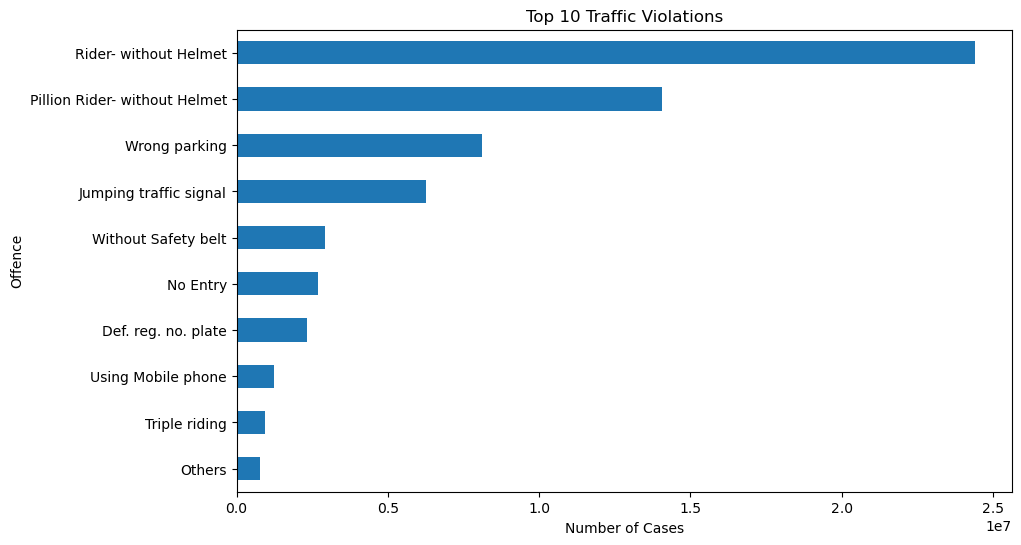

In [26]:
top_offences.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Traffic Violations")
plt.xlabel("Number of Cases")
plt.ylabel("Offence")

plt.show()

## Insight: 
Helmet-related violations dominate the recorded traffic violations, with rider and pillion helmet violations accounting for the largest volumes.

This indicates that two-wheeler safety compliance is a major enforcement concern in the dataset.

## Violation category analysis

In [27]:
category_analysis = (
    violations.groupby("category")["cases"]
    .sum()
    .sort_values(ascending=False)
)

category_analysis

category
Helmet & seatbelt      41366905.0
Signal & lane           9668683.0
Parking                 9135804.0
Vehicle & documents     2907860.0
Overloading             1855095.0
Distraction             1233354.0
Dangerous driving        817090.0
Auto/taxi conduct        801698.0
Other                    767923.0
Noise                     61177.0
Name: cases, dtype: float64

## insight: 
The violation categories show that road-safety-related offences, particularly helmet and safety-compliance violations, contribute substantially to the overall enforcement workload. 
This highlights the importance of preventive awareness in addition to penalty-based enforcement.

## Violation trend over time

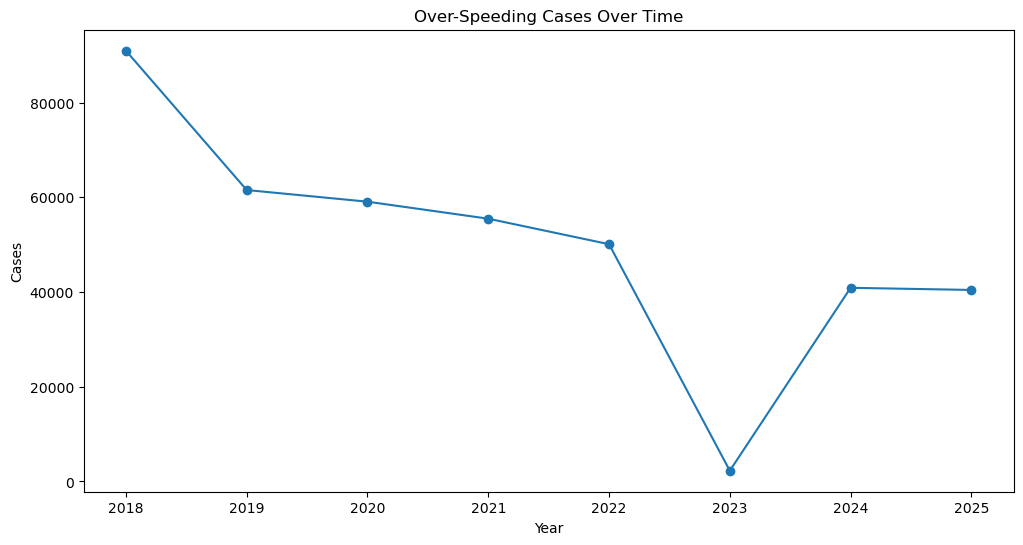

In [28]:
overspeeding = violations[
    violations["offence"] == "Over speeding"
]

plt.figure(figsize=(12,6))

plt.plot(
    overspeeding["year"],
    overspeeding["cases"],
    marker="o"
)

plt.title("Over-Speeding Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Cases")

plt.show()

## Insight:
The over-speeding trend shows how speeding-related enforcement changes over time.
Significant increases may indicate periods of greater enforcement activity or increased detection of speeding violations.

## Fine & enforcement analysis

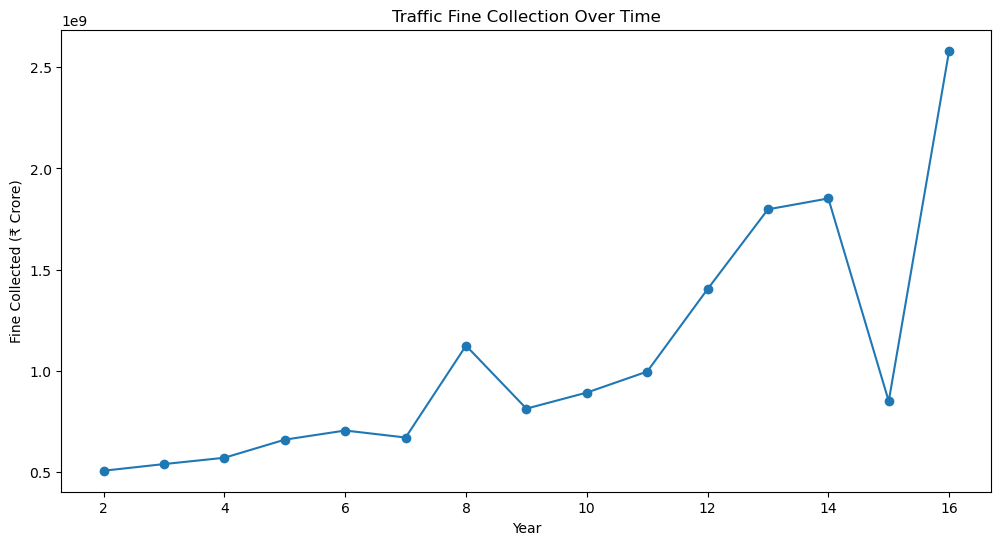

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    fines["year"],
    fines["total_fine_inr_crore"],
    marker="o"
)

plt.title("Traffic Fine Collection Over Time")
plt.xlabel("Year")
plt.ylabel("Fine Collected (₹ Crore)")

plt.show()

## Insight: 
Fine collection varies across the years, reflecting changes in enforcement activity, recorded violations, and the types of offences being penalized.

## Enforcement cases

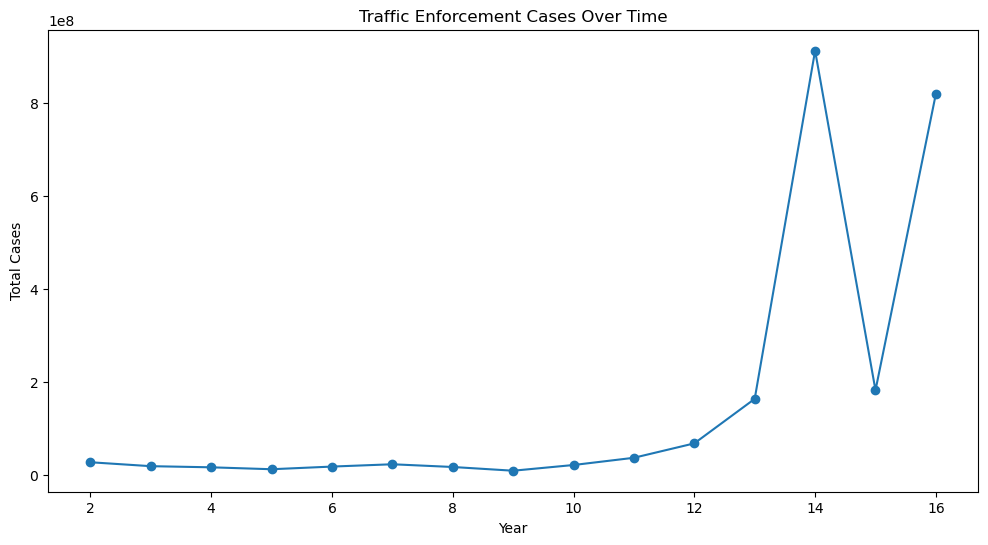

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    fines["year"],
    fines["total_cases"],
    marker="o"
)

plt.title("Traffic Enforcement Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cases")

plt.show()

## Insight:
The number of enforcement cases changes over time, indicating variations in traffic-law enforcement activity.
Comparing enforcement cases with crash trends can help evaluate whether enforcement intensity changes alongside road-safety outcomes.

## Automation analysis

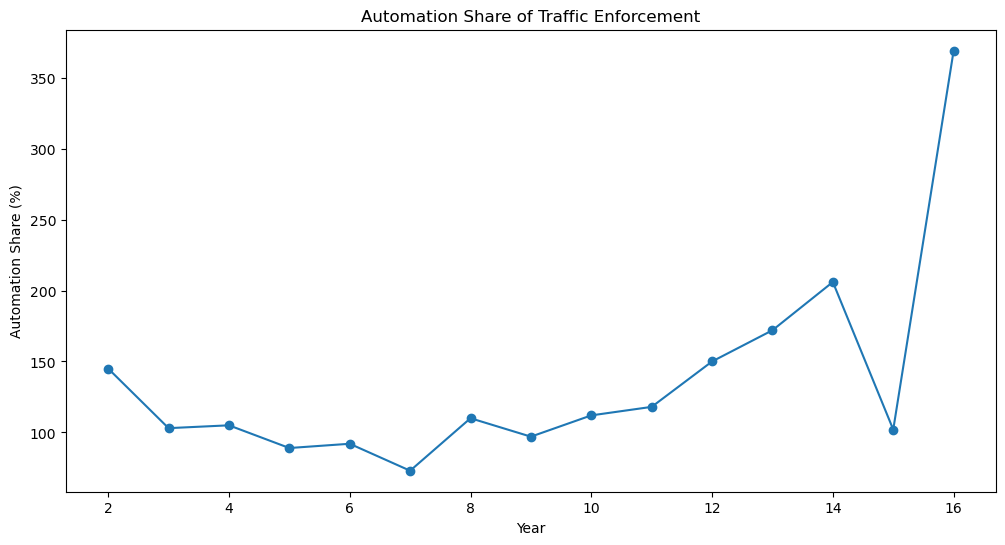

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    fines["year"],
    fines["automation_share_pct"],
    marker="o"
)

plt.title("Automation Share of Traffic Enforcement")
plt.xlabel("Year")
plt.ylabel("Automation Share (%)")

plt.show()

## Insight: 
The automation analysis shows the growing role of technology in traffic enforcement. 
Increasing automation share indicates greater reliance on technology-based detection and monitoring mechanisms.

## Drink-driving analysis

In [35]:
drink_drive = pd.read_excel(
    file_path,
    sheet_name="Drink_Drive_Monthly",
    header=1
)

drink_drive.head()

,1,year,month_num,month,drink_drive_cases
0,NaN,NaN,NaN,NaN,NaN
1,2.0,2016.0,1.0,January,4990.0
2,3.0,2016.0,2.0,February,5158.0
3,4.0,2016.0,3.0,March,5641.0
4,5.0,2016.0,4.0,April,3434.0


In [36]:
# Remove completely empty rows
drink_drive = drink_drive.dropna(how="all")

# Keep only rows where year and month_num are available
drink_drive = drink_drive.dropna(
    subset=["year", "month_num"]
)
drink_drive["year"] = drink_drive["year"].astype(int)
drink_drive["month_num"] = drink_drive["month_num"].astype(int)

print(drink_drive.head())
print(drink_drive.shape)

     1  year  month_num     month  drink_drive_cases
1  2.0  2016          1   January             4990.0
2  3.0  2016          2  February             5158.0
3  4.0  2016          3     March             5641.0
4  5.0  2016          4     April             3434.0
5  6.0  2016          5       May             1829.0
(26, 5)


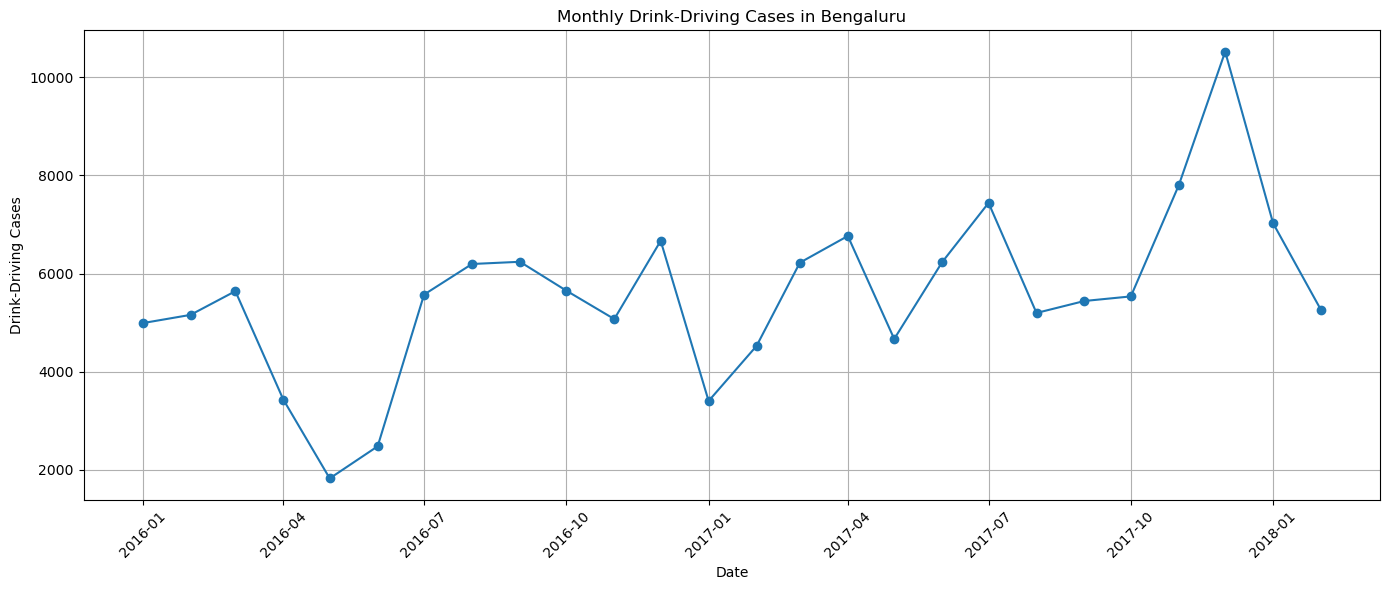

In [40]:
# Create date column
drink_drive["date"] = pd.to_datetime(
    drink_drive["year"].astype(str) + "-" +
    drink_drive["month_num"].astype(str) + "-01"
)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    drink_drive["date"],
    drink_drive["drink_drive_cases"],
    marker="o"
)

plt.title("Monthly Drink-Driving Cases in Bengaluru")
plt.xlabel("Date")
plt.ylabel("Drink-Driving Cases")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Insight:
Drink-driving cases fluctuate across months, indicating possible seasonal patterns in enforcement or recorded incidents. 
Identifying consistently high-case months can help authorities plan targeted enforcement campaigns.

## Correlation Heatmap

In [66]:
relationship = pd.merge(
    city[
        [
            "year",
            "total_crashes",
            "fatal_crashes",
            "killed",
            "non_fatal_crashes",
            "fatality_rate_pct"
        ]
    ],
    fines[
        [
            "year",
            "total_cases",
            "total_fine_inr_crore",
            "automation_share_pct"
        ]
    ],
    on="year",
    how="inner"
)
print("Relationship dataset created successfully!")
display(relationship)

Relationship dataset created successfully!


,year,total_crashes,fatal_crashes,killed,non_fatal_crashes,fatality_rate_pct,total_cases,total_fine_inr_crore,automation_share_pct
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,7469.0,2007.0,957.0,981.0,8426.0,26609275.0,5.056615e+08,145.0
2,3.0,6908.0,2008.0,864.0,892.0,7772.0,18174654.0,5.385179e+08,103.0
3,4.0,6138.0,2009.0,737.0,761.0,6875.0,15735560.0,5.698093e+08,105.0
4,5.0,5667.0,2010.0,816.0,858.0,6483.0,11589024.0,6.592214e+08,89.0
5,6.0,5297.0,2011.0,727.0,762.0,6024.0,17314941.0,7.044383e+08,92.0
6,7.0,4767.0,2012.0,740.0,760.0,5507.0,22298025.0,6.697615e+08,73.0
7,8.0,4493.0,2013.0,737.0,771.0,5230.0,16429002.0,1.123853e+09,110.0
8,9.0,4293.0,2014.0,711.0,737.0,5004.0,8390700.0,8.125730e+08,97.0
9,10.0,4114.0,2015.0,714.0,740.0,4828.0,20689035.0,8.918846e+08,112.0


In [67]:
correlation = relationship[
    [
        "total_crashes",
        "fatal_crashes",
        "killed",
        "non_fatal_crashes",
        "fatality_rate_pct",
        "total_cases",
        "total_fine_inr_crore",
        "automation_share_pct"
    ]
].corr()

display(correlation.round(2))

,total_crashes,fatal_crashes,killed,non_fatal_crashes,fatality_rate_pct,total_cases,total_fine_inr_crore,automation_share_pct
total_crashes,1.00,-0.84,0.84,0.85,1.00,-0.53,-0.65,-0.45
fatal_crashes,-0.84,1.00,-0.81,-0.81,-0.84,0.64,0.80,0.58
killed,0.84,-0.81,1.00,1.00,0.85,-0.30,-0.58,-0.33
non_fatal_crashes,0.85,-0.81,1.00,1.00,0.86,-0.31,-0.58,-0.33
fatality_rate_pct,1.00,-0.84,0.85,0.86,1.00,-0.52,-0.65,-0.45
total_cases,-0.53,0.64,-0.30,-0.31,-0.52,1.00,0.82,0.83
total_fine_inr_crore,-0.65,0.80,-0.58,-0.58,-0.65,0.82,1.00,0.89
automation_share_pct,-0.45,0.58,-0.33,-0.33,-0.45,0.83,0.89,1.00


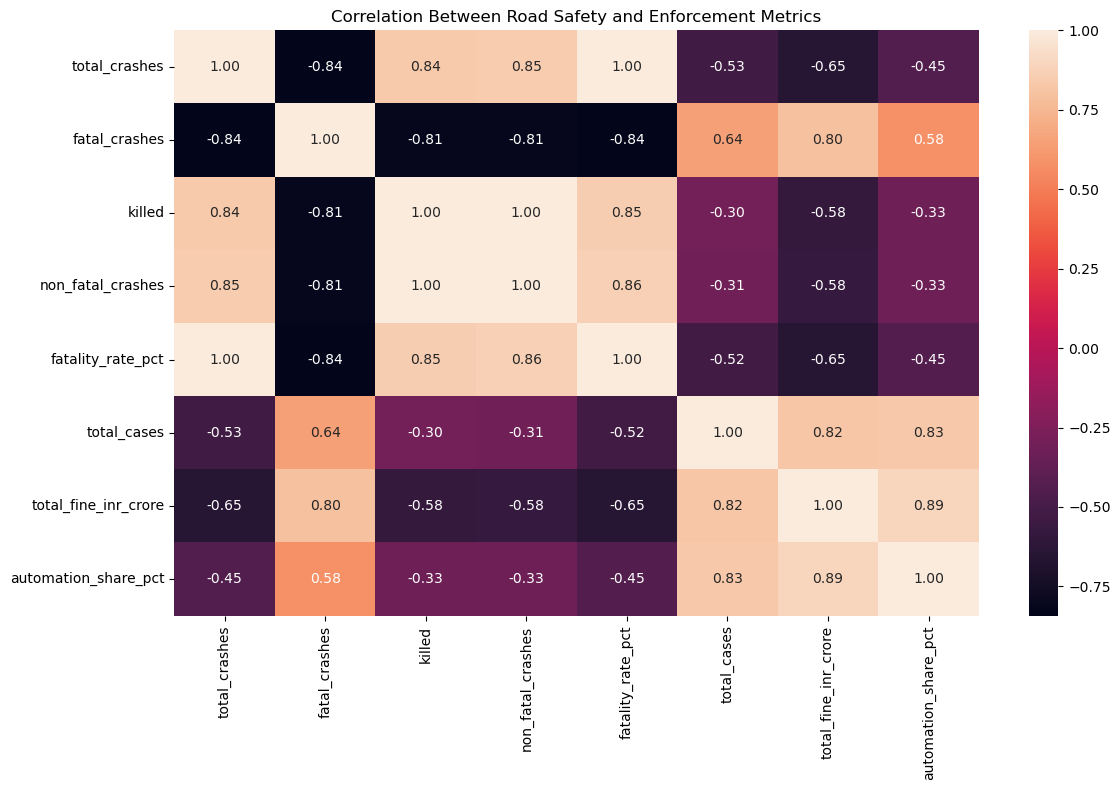

In [68]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Road Safety and Enforcement Metrics")
plt.tight_layout()
plt.show()

## Insight:
The correlation heatmap provides an overview of how road-safety indicators and enforcement indicators move together. 
 Strong positive correlations indicate that two variables tend to increase or decrease together, while negative correlations indicate an inverse relationship.

## KPI section

In [62]:

# 1. Total Crashes
total_crashes = city["total_crashes"].sum()

# 2. Fatal Crashes
fatal_crashes = city["fatal_crashes"].sum()

# 3. People Killed
people_killed = city["killed"].sum()

# 4. People Injured
people_injured = station["injured"].sum()

# 5. Fatality Rate
fatality_rate = (people_killed / total_crashes) * 100

# 6. Total Traffic Violations
total_violations = violations["cases"].sum()

# 7. Total Fines Collected
total_fines_crore = fines["total_fine_inr_crore"].sum()
total_fines_inr = total_fines_crore * 10_000_000

# 8. Average Fine per Case
total_fine_cases = fines["total_cases"].sum()
average_fine = total_fines_inr / total_fine_cases

# 9. Highest-Risk Station
station_risk = (
    station.groupby("station")
    .agg(
        total_crashes=("total_crashes", "sum"),
        killed=("killed", "sum")
    )
)
station_risk["fatality_rate"] = (
    station_risk["killed"] /
    station_risk["total_crashes"] * 100
)
highest_risk_station = (
    station_risk["fatality_rate"]
    .idxmax()
)

# 10. Highest Violation Category
highest_violation_category = (
    violations.groupby("offence")["cases"]
    .sum()
    .idxmax()
)

highest_violation_cases = (
    violations.groupby("offence")["cases"]
    .sum()
    .max()
)

In [69]:
kpi_table = pd.DataFrame({
    "KPI": [
        "Total Crashes",
        "Fatal Crashes",
        "People Killed",
        "People Injured",
        "Fatality Rate",
        "Total Traffic Violations",
        "Total Fines Collected",
        "Average Fine per Case",
        "Highest-Risk Station",
        "Highest Violation Category"
    ],
    
   "Value": [
        f"{total_crashes:,.0f}",
        f"{fatal_crashes:,.0f}",
        f"{people_killed:,.0f}",
        f"{people_injured:,.0f}",
        f"{fatality_rate:.2f}%",
        f"{total_violations:,.0f}",
        f"₹{total_fines_crore:,.2f} Crore",
        f"₹{average_fine:,.2f}",
        highest_risk_station,
        highest_violation_category
    ]
})
display(kpi_table)

,KPI,Value
0,Total Crashes,"88,565"
1,Fatal Crashes,"38,304"
2,People Killed,"14,360"
3,People Injured,"28,288"
4,Fatality Rate,16.21%
5,Total Traffic Violations,"68,615,589"
6,Total Fines Collected,"₹15,954,679,187.00 Crore"
7,Average Fine per Case,"₹68,259,869.28"
8,Highest-Risk Station,North East
9,Highest Violation Category,Rider- without Helmet


## 🔑 Key Insights
1. 🚗 Road crashes show significant variation over time

The city-level dataset contains 20 records, with 19 non-null observations used in the current statistical analysis. The crash indicators vary considerably across the observed period, showing that road-safety conditions have not remained constant.

Key Insight: Road crashes fluctuate over time, so individual years with major increases or decreases should be investigated rather than relying only on the overall average.

2. 🚨 Fatalities are an important measure of crash severity

The analysis tracks both fatal crashes and people killed, allowing crash frequency to be separated from crash severity. The notebook's current city-level data shows fatalities varying substantially across the observed years.

Key Insight: Reducing the number of crashes is important, but reducing the severity of crashes and preventing fatalities should remain a primary road-safety objective.

3. 🚓 Some stations have substantially higher fatality counts

The station analysis identifies North East as the station with the highest recorded fatalities in the current analysis, followed by Whitefield and North. North East records 621 deaths, Whitefield 335, and North 307.

Key Insight: Road-safety risk is geographically concentrated, making high-fatality stations important candidates for targeted investigation and intervention.

4. 🪖 Helmet violations are the biggest enforcement issue

Your violation analysis shows:

Rider without Helmet — 24,401,960
Pillion Rider without Helmet — 14,056,994
Wrong Parking — 8,111,182
Jumping Traffic Signal — 6,264,062
Without Safety Belt — 2,907,951

Key Insight: Helmet-related violations dominate the recorded violations, highlighting two-wheeler safety compliance as one of the most important enforcement priorities.

5. 🚦 Traffic-safety behaviour needs stronger compliance

The high frequency of helmet, safety-belt, signal, and parking violations indicates that enforcement is not limited to one type of traffic behaviour.

Key Insight: A combination of enforcement, awareness campaigns, and targeted interventions is needed to improve compliance with basic traffic-safety rules.

6. 💰 Enforcement and fine collection are closely connected

Your project includes yearly enforcement cases, total fines, average fine per case, and automation share, allowing enforcement activity to be studied alongside financial outcomes.

Key Insight: Fine collection can be used as an indicator of enforcement activity, but it should not be treated as the primary measure of road-safety success.

7. 🤖 Automation is an important enforcement indicator

The project specifically analyzes the automation share of traffic enforcement, allowing you to examine how technology-based enforcement changes over time.

Key Insight: Increasing use of automated enforcement can improve the scale and consistency of traffic monitoring, while its relationship with road-safety outcomes should be evaluated carefully.

8. 🍺 Drink-driving cases show monthly variation

The Drink_Drive_Monthly dataset contains monthly records with year, month number, month name, and drink-driving cases. For example, the 2016 records show 4,990 cases in January, 5,158 in February, 5,641 in March, 3,434 in April, and 1,829 in May.

Key Insight: Drink-driving cases vary across months, making monthly analysis useful for identifying periods where targeted enforcement may be particularly important.

9. 🔗 Road safety and enforcement indicators have relationships

The project includes a correlation analysis between crash, fatality, enforcement, fine, and automation variables.

Key Insight: Correlation analysis helps identify variables that move together, but correlations should be interpreted as associations and not as proof of causation.

## 🎯 Final Conclusion

This analysis provides a data-driven overview of Bengaluru's road-safety and traffic-enforcement situation. The findings show that road crashes and fatalities vary across time and that road-safety risk is not evenly distributed across locations.

Station-level analysis highlights specific areas with higher crash and fatality burdens, while traffic-violation analysis shows that helmet-related violations are particularly prominent. The analysis of enforcement cases, fines, automation, and drink-driving provides additional insight into the broader traffic-management environment.

Overall, the analysis suggests that Bengaluru's road-safety strategy can benefit from targeted enforcement in high-risk locations, stronger helmet and safety-compliance measures, monitoring of drink-driving patterns, and effective use of technology-based enforcement.

The project demonstrates how data analytics can transform raw traffic and road-safety data into actionable insights for better decision-making, targeted enforcement, and road-safety planning.